Netflix Titles Analysis
Isaac Moua | dpn34
CS 4739G - Data Analysis & Visualization

Netflix Investigation Questions:
1. How the number of titles added to Netflix has changed over time.
2. Whether Movies and TV Shows differ in their typical duration.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv("../netflix_titles.csv")
df.head()


print("dataset shape: ", df.shape)
print("\,\nColumns: ")
print(df.columns)
print("\nMissing Values: ")
print(df.isnull().sum())

dataset shape:  (8807, 12)
\,
Columns: 
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Missing Values: 
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [29]:
df = df.drop_duplicates()

df['country'] = df['country'].fillna('unknown')
df = df.dropna(subset=['duration'])
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year

def extractMovieMinute(duration):
        if "min" in duration:
                return int(duration.split(" ")[0])
        else:
                return np.nan

df['movie_minutes'] = df['duration'].apply(extractMovieMinute)

def extractTvSeason(duration):
        if "Season" in duration:
                return int(duration.split(" ")[0])
        else:
                return np.nan
        
df['tv_seasons'] = df['duration'].apply(extractTvSeason)


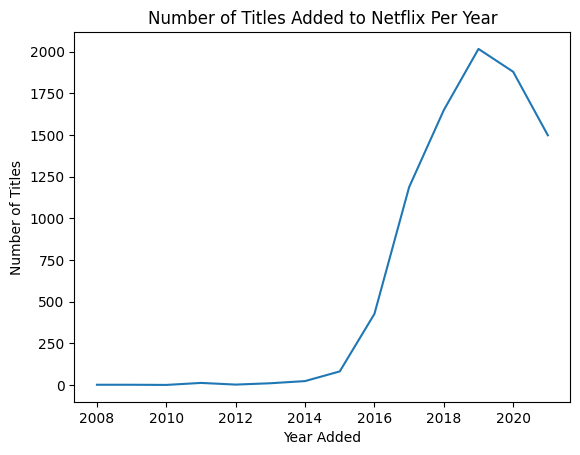

In [30]:
titlesPerYear = df.groupby('year_added').size()
titlesPerYear.head()

plt.figure()
titlesPerYear.plot()
plt.title("Number of Titles Added to Netflix Per Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()

This graph shows a rapid increase in titles within the 2016 - 2020 year. <br>
This analysis shows that within that timeframe Netflix had a bloom in <br> 
title releases for the streaming service.

<h1>Q2 Analysis:</h1>
<h2>Movies VS Tv Shows by Rating</h2>
-------------------------------------------------------------------

In [26]:
movies = df[df['type'] == "Movie"]
tvShows = df[df['type'] == "TV Show"]

avgMovieDuration = movies['movie_minutes'].mean()
avgTvSeasons = tvShows['tv_seasons'].mean()

print("Average Movie Duration (minutes):", avgMovieDuration)
print("Average TV Show Seasons:", avgTvSeasons)

Average Movie Duration (minutes): 99.57718668407311
Average TV Show Seasons: 1.764947683109118


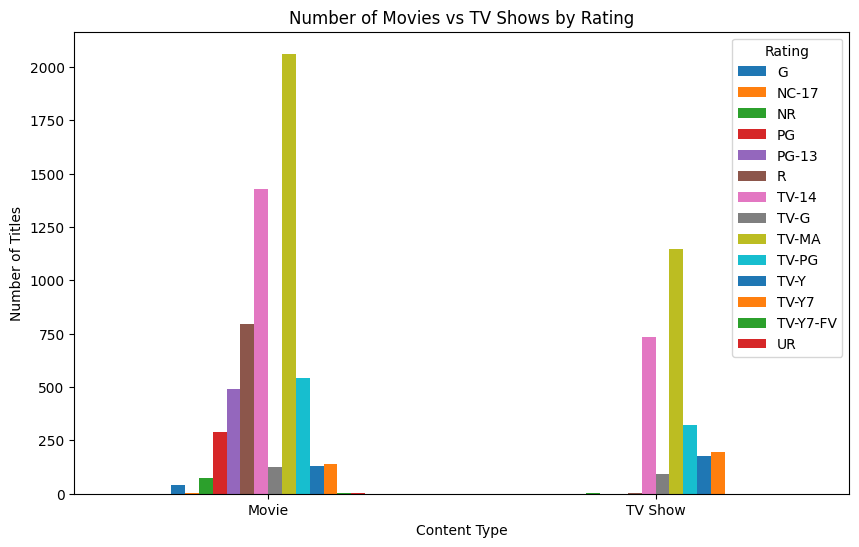

In [27]:
rating_counts = df.groupby(['type', 'rating']).size().unstack(fill_value=0)
rating_counts.plot(kind='bar', figsize=(10,6))

plt.title("Number of Movies vs TV Shows by Rating")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.legend(title="Rating")
plt.show()


This graph shows that the 'movies' tend to have a more diverse variety of rating types. <br>
However, we can also see that both 'tv shows' and 'movies' cater towards "TV-14" and "TV-MA" <br>
as those ratings reach the broader target audience.